# Baseline Machine Learning for Store Sales Forecasting

This notebook builds a strong baseline for the Kaggle *Store Sales - Time Series Forecasting* dataset.

What this notebook covers:
- load and merge the raw retail datasets
- create leakage-safe features
- build a chronological train/validation/test split
- train simple baseline regressors
- evaluate the models with forecasting metrics

The goal is not to over-engineer the first model. The goal is to create a stable, explainable baseline that can be improved later with LSTM, Transformer, or more advanced gradient-boosted models.

## 1. Setup and imports

This section loads the standard scientific Python stack and points the notebook to the project root so the `src` package can be imported cleanly.

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
from pathlib import Path
import pandas as pd

data_dir = Path("/kaggle/input/datasets/montahalassouedd/processed-data-forecasting2")

train_df = pd.read_parquet(data_dir / "train.parquet")
val_df = pd.read_parquet(data_dir / "val.parquet")
test_df = pd.read_parquet(data_dir / "test.parquet")

## 2. Load and preprocess the retail panel

The preprocessing module handles raw loading, safe merges, holiday expansion, oil alignment, transaction cleaning, and train-based outlier capping.

Important design choice: the preprocessing is fit on training data only, so the validation and test sets do not leak future information into the cleaning step.

In [10]:
# Fonction pour calculer la métrique officielle de Kaggle
def rmsle(y_true, y_pred):
    # On force les valeurs à 0 minimum pour éviter les erreurs de log
    y_true = np.maximum(0, np.array(y_true))
    y_pred = np.maximum(0, np.array(y_pred))
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

In [11]:
# Step 1: remember your cutoff dates before concatenating
train_end = train_df['date'].max()
val_end   = val_df['date'].max()

# Step 2: concatenate and sort
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
full_df = full_df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# Step 3: compute all lag features grouped by store+family
grp = full_df.groupby(['store_nbr', 'family'])['sales']

full_df['lag_1']  = grp.shift(1)
full_df['lag_7']  = grp.shift(7)
full_df['lag_14'] = grp.shift(14)
full_df['lag_28'] = grp.shift(28)

full_df['roll_mean_7']  = grp.shift(1).transform(lambda x: x.rolling(7,  min_periods=1).mean())
full_df['roll_mean_28'] = grp.shift(1).transform(lambda x: x.rolling(28, min_periods=1).mean())
full_df['roll_std_7']   = grp.shift(1).transform(lambda x: x.rolling(7,  min_periods=1).std()).fillna(0)

# Step 4: lag on transactions (store-level signal, not store+family)
full_df['transactions_lag_1'] = full_df.groupby('store_nbr')['transactions'].shift(1)

# Step 5: re-split by date
train_df = full_df[full_df['date'] <= train_end].copy()
val_df   = full_df[(full_df['date'] > train_end) & (full_df['date'] <= val_end)].copy()
test_df  = full_df[full_df['date'] > val_end].copy()

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print(f"\nNew lag columns: {[c for c in full_df.columns if 'lag' in c or 'roll' in c]}")
print(f"\nNaN count in lag_1 (train): {train_df['lag_1'].isna().sum()}")

Train: (2918916, 31), Val: (53460, 31), Test: (28512, 31)

New lag columns: ['lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'transactions_lag_1']

NaN count in lag_1 (train): 1782


In [12]:
# Liste des colonnes de texte à convertir
cat_features = ['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name', 'store_nbr', 'cluster']

for df in [train_df, val_df, test_df]:
    for col in cat_features:
        if col in df.columns:
            df[col] = df[col].astype('category')

## 4. Define baseline target and features

For a first baseline, we predict daily sales directly. The feature set includes time-derived variables, lagged demand, rolling statistics, promotions, transactions, oil, and categorical store/family identifiers.

In [13]:
# Colonnes à ne pas donner au modèle (la date et les transactions futures)
drop_cols = ['sales', 'date', 'transactions', 'holiday_type']

X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['sales'].astype(float)

X_val = val_df.drop(columns=drop_cols, errors='ignore')
y_val = val_df['sales'].astype(float)

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['sales'].astype(float)

# Convert categoricals for XGBoost
cat_cols = X_train.select_dtypes(include='category').columns.tolist()
for df in [X_train, X_val, X_test]:
    for col in cat_cols:
        df[col] = df[col].cat.codes

print(f"X_train: {X_train.shape}")
print(f"Features: {X_train.columns.tolist()}")
print(f"\nNaN counts:\n{X_train.isnull().sum()[X_train.isnull().sum() > 0]}")


X_train: (2918916, 28)
Features: ['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'type_y', 'locale', 'locale_name', 'transferred', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'has_promotion', 'is_holiday', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'transactions_lag_1']

NaN counts:
lag_1                  1782
lag_7                 12474
lag_14                24948
lag_28                49896
roll_mean_7               1
roll_mean_28              1
transactions_lag_1       54
dtype: int64


In [14]:
lag_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_28',
            'roll_mean_7', 'roll_mean_28', 'roll_std_7',
            'transactions_lag_1']

for df in [X_train, X_val, X_test]:
    for col in lag_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

print("NaN counts after fill:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print("(empty = no NaNs remaining )")

NaN counts after fill:
Series([], dtype: int64)
(empty = no NaNs remaining )


In [15]:
# Oil price cleaning — interpolate gaps and add smoothed trend
for df in [train_df, val_df, test_df]:
    if 'dcoilwtico' in df.columns:
        df['dcoilwtico'] = df['dcoilwtico'].interpolate(method='linear').bfill()
        df['oil_trend'] = df['dcoilwtico'].rolling(window=3, min_periods=1).mean()

In [16]:
print(train_df.columns)

Index(['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state',
       'type_x', 'cluster', 'dcoilwtico', 'transactions', 'type_y', 'locale',
       'locale_name', 'transferred', 'day_of_week', 'month', 'quarter',
       'is_weekend', 'is_month_start', 'is_month_end', 'has_promotion',
       'is_holiday', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7',
       'roll_mean_28', 'roll_std_7', 'transactions_lag_1', 'oil_trend'],
      dtype='object')


In [17]:
!pip install xgboost

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import xgboost as xgb
# On crée le modèle avec des réglages plus fins
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',      # Indispensable pour enable_categorical
    enable_categorical=True, # Indispensable pour nos types 'category'
    early_stopping_rounds=50,
    n_jobs=-1
)

In [19]:
import numpy as np

# 1. On transforme la cible (Sales) en Log
# log1p fait log(1 + x) pour éviter les erreurs sur les ventes à 0
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [20]:
# 2. On entraîne le modèle sur ces logs
# Regarde bien : on passe y_train_log et y_val_log
# Entraînement avec arrêt automatique
model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=100
)

[0]	validation_0-rmse:2.51388
[100]	validation_0-rmse:0.38344
[188]	validation_0-rmse:0.38362


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [21]:
# 1. Prédictions (on sort du log avec expm1)
val_preds_log = model.predict(X_val)
val_preds = np.expm1(val_preds_log)
val_preds = np.maximum(0, val_preds)

# 2. Récupération des valeurs réelles alignées
# On transforme le log de validation en ventes réelles
y_true_val = np.expm1(y_val_log) 

# 3. Calcul final
print(f"RMSLE réel: {rmsle(y_true_val, val_preds):.4f}")
print(f"MAE finale: {mean_absolute_error(y_true_val, val_preds):.2f}")

RMSLE réel: 0.3826
MAE finale: 63.20


# Tuning propre avec Optuna

In [22]:
!pip install optuna

In [23]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [24]:
import optuna
import xgboost as xgb

def objective(trial):
    # 1. On définit les suggestions pour Optuna
    # Note : 'early_stopping_rounds' est mis directement ici
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist',
        'device': 'cuda', # Utilise 'cuda' pour le GPU de Kaggle
        'enable_categorical': True,
        'random_state': 42,
        'early_stopping_rounds': 30 # Le modèle s'arrêtera s'il n'y a plus de progrès après 30 rounds
    }

    # 2. On crée le modèle
    model = xgb.XGBRegressor(**param)
    
    # 3. Entraînement (sans early_stopping_rounds dans le fit)
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False
    )
    
    # 4. On calcule le score sur la validation
    # On transforme les prédictions log -> sales pour calculer le vrai RMSLE
    preds_log = model.predict(X_val)
    score = rmsle(np.expm1(y_val_log), np.expm1(preds_log))
    
    return score

# Lancement de l'étude
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("--- OPTIMISATION TERMINÉE ---")
print("Meilleurs paramètres :", study.best_params)
print("Meilleur RMSLE :", study.best_value)

[I 2026-05-04 21:05:01,169] A new study created in memory with name: no-name-d5f6f2bd-fc97-4478-9ab9-46b9124cb10c
[I 2026-05-04 21:05:07,120] Trial 0 finished with value: 0.3859356237521076 and parameters: {'n_estimators': 556, 'max_depth': 5, 'learning_rate': 0.0744101037900032, 'subsample': 0.6903319242126299, 'colsample_bytree': 0.6530678231280057, 'min_child_weight': 1}. Best is trial 0 with value: 0.3859356237521076.
[I 2026-05-04 21:05:18,018] Trial 1 finished with value: 0.3877186554106904 and parameters: {'n_estimators': 564, 'max_depth': 4, 'learning_rate': 0.015722238683444384, 'subsample': 0.6999585278578196, 'colsample_bytree': 0.7933476209017867, 'min_child_weight': 6}. Best is trial 0 with value: 0.3859356237521076.
[I 2026-05-04 21:05:29,805] Trial 2 finished with value: 0.38478211363157744 and parameters: {'n_estimators': 1101, 'max_depth': 5, 'learning_rate': 0.013998198025388146, 'subsample': 0.7557074366635279, 'colsample_bytree': 0.8356814642433685, 'min_child_weigh

--- OPTIMISATION TERMINÉE ---
Meilleurs paramètres : {'n_estimators': 1485, 'max_depth': 8, 'learning_rate': 0.03162746873290299, 'subsample': 0.9040866398709001, 'colsample_bytree': 0.9358739160156517, 'min_child_weight': 1}
Meilleur RMSLE : 0.3738598887352197


In [ ]:
import joblib

# Sauvegarder le modèle final
joblib.dump(final_model, 'xgboost_store_sales_model.pkl')

# Sauvegarder aussi l'étude Optuna (pour garder une trace de tes recherches)
joblib.dump(study, 'optuna_study.pkl')

print("Modèle et étude sauvegardés avec succès !")

In [39]:
# On récupère les meilleurs réglages d'Optuna
best_params = study.best_params
# On s'assure d'ajouter les paramètres fixes nécessaires
best_params.update({
    'tree_method': 'hist',
    'device': 'cuda', 
    'enable_categorical': True,
    'random_state': 42,
    'early_stopping_rounds': 50
})

# Entraînement du modèle final
model = XGBRegressor(**best_params, n_jobs=-1)
model.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=100
)

# Prédiction pour Kaggle
test_preds = np.expm1(model.predict(X_test))
test_preds = np.maximum(0, test_preds)



[0]	validation_0-rmse:2.56056
[100]	validation_0-rmse:0.39421
[200]	validation_0-rmse:0.37853
[300]	validation_0-rmse:0.37722
[400]	validation_0-rmse:0.37628
[500]	validation_0-rmse:0.37556
[600]	validation_0-rmse:0.37509
[700]	validation_0-rmse:0.37492
[800]	validation_0-rmse:0.37451
[900]	validation_0-rmse:0.37419
[1000]	validation_0-rmse:0.37391
[1100]	validation_0-rmse:0.37386
[1200]	validation_0-rmse:0.37366
[1300]	validation_0-rmse:0.37355
[1400]	validation_0-rmse:0.37342
[1484]	validation_0-rmse:0.37332


In [45]:
# Model was trained on log1p(sales), so predictions are in log space
val_pred_log  = model.predict(X_val)
test_pred_log = model.predict(X_test)

# Convert back to real sales
val_pred_actual  = np.expm1(val_pred_log)
test_pred_actual = np.expm1(test_pred_log)

# y_val and y_test are raw sales — this is correct
val_rmsle  = rmsle(y_val, val_pred_actual)
test_rmsle = rmsle(y_test, test_pred_actual)

print(f"Val RMSLE:  {val_rmsle:.4f}  (was 0.4333)")
print(f"Test RMSLE: {test_rmsle:.4f}  (was 0.4765)")
print(f"Gap:        {test_rmsle - val_rmsle:.4f}  (was 0.0432)")

Val RMSLE:  0.3733  (was 0.4333)
Test RMSLE: 0.3863  (was 0.4765)
Gap:        0.0130  (was 0.0432)


# k-fold cross validation 

In [51]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

y_train_log = np.log1p(y_train)

scores = cross_val_score(
    cv_model,
    X_train,
    y_train_log,
    cv=tscv,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("RMSE log per fold:", rmse_scores.round(4))
print("Mean RMSE log:   ", rmse_scores.mean().round(4))
print("Std RMSE log:    ", rmse_scores.std().round(4))

RMSE log per fold: [0.4585 0.3996 0.4138 0.3814 0.3562]
Mean RMSE log:    0.4019
Std RMSE log:     0.0342


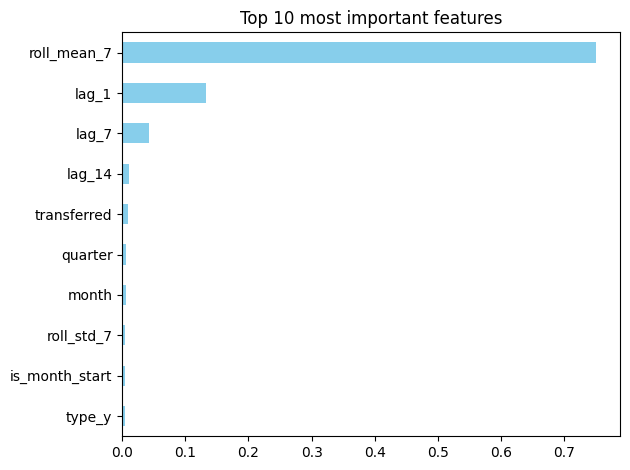

In [47]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X_train.columns)

feat_importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 most important features")
plt.tight_layout()
plt.show()